# Practice with Fourier Neural Operator (FNOs)

Essentially a learnable fourier transform, FNOs lend themselves really nicely to problems involving optical evolutions in time and distance, such as optical propagation. This blog post by the creator of FNOs gives a handy summary of what they're all about: https://zongyi-li.github.io/blog/2020/fourier-pde/


Propagating a beam using Fresnel Propagation is actually a specific example of something that the fourier layer can model exactly, so it's the perfect baseline to determine if things are doing OK. 

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift

# CONSTANTS 

nm = 1e-9 
um = 1e-6
mm = 1e-3
cm = 1e-2

Useful functions

In [ ]:
'''
Cartesian to Polar coordinates 
x,y - x and y coordinates
'''

def cart2pol(x, y):
    rho = np.sqrt((x)**2 + (y)**2)
    phi = np.arctan2(y, x)
    return(rho, phi)


'''
# Generates the normalized LG field.
# Expression adapted from Saleh. The normalization factor is adapted from wikipedia, 
# then modified silghtly so that the LG mode expression in wikipedia and Saleh are equivalent
#
# RHO, PHI - polar coordinate field
# ell - azimuthal index
# p - radial index
# w0 - beam waist (in units of ... w0)
# h - grid step size
# z - propagation distance
# k - wavenumber
'''

def LG(RHO,PHI,ell,p,w0,h,z,k):
    wL = (2*np.pi)/(k)
    z_o = np.pi*w0**2/wL
    w_z = lambda z: w0*np.sqrt(1 + (z/z_o)**2)
    R_z = lambda z: z*(1+(z_o/z)**2)
    zeta_z = lambda z: np.arctan(z/z_o)

    N_factor = 1

    if (z == 0):
        AK = N_factor * np.exp(-(RHO/w0)**2) * ((RHO/w0)**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w0)**2) * np.exp(1j * ell * PHI))
    else:
        AK = N_factor * (w0/w_z(z)) * np.exp(-(RHO/w_z(z))**2) * ((RHO/w_z(z))**abs(ell) * 
                                                    scipy.special.eval_genlaguerre(p,abs(ell),2*(RHO/w_z(z))**2) * np.exp(1j * ell * PHI))*np.exp(-1j*k*z) * np.exp(-1j*k*(RHO**2/(2*R_z(z)))) * np.exp(1j*(abs(ell)+2*p + 1)*zeta_z(z))
    reNormFactor = np.sqrt(np.sum(np.conj(AK)*AK * h**2)) # We use this to further normalize the field with respect to 
    return  AK/reNormFactor


'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
phase - boolean - controls whether or not we wanna plot the phase
'''

def TotInt(Ex, phase=True, cmappy='hot', enable_colourbar='True'):

    if (phase==False): # Just plot the intensity
        fig, ax = plt.subplots(1,1, figsize=(8,4))
        #ax.set_title('Intensity')
        intensity = ax.imshow(abs(Ex)**2, cmap=cmappy)
        ax.axis('off')
        if (enable_colourbar):
            cbar = fig.colorbar(intensity, ax=ax)
    
    else:

        fig, ax =  plt.subplots(1,2,figsize=(8,4))
        ax[0].set_title('Intensity')
        intensity = ax[0].imshow(abs(Ex)**2,cmap=cmappy)
        ax[0].axis('off')
        cbar=fig.colorbar(intensity, ax=ax[0])
        
        ax[1].set_title('Phase')
        phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
        ax[1].axis('off')
        if (enable_colourbar):
            cbar = fig.colorbar(phase, ax=ax[1])
        #cbar=fig.colorbar(phase, ax=ax[1])
        plt.show()


'''
This propagates the beam using a Fresnal Diffraction Transfer Function approach. 

PARAMETERS
u1 - source plane
L - length of the numerical window (in units of w0)
la - lambda (m-1)
z - propagation distance (w0)
'''

def propTF(u1,L,la,z):
    M,nn=u1.shape
    dx=L/M
    fx=np.arange(-1/(2*dx),1/(2*dx),1/L)
    Fx, Fy = np.meshgrid(fx, fx)
    H=np.exp(-1j*np.pi*la*z*(Fx**2+Fy**2))
    
    H = fftshift(H)
    U2=H*fft2(fftshift(u1))
    u2=ifftshift(ifft2(U2))

    
    return u2 



Define the coordinate space

In [4]:
# Define the coordinate space 
la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)
w0 = 0.10*mm

# What is the Rayleigh range of this beam? 

zR = 0.50*k*w0**2
print(f"Rayleigh Range: {zR}")

# Space definition 
dx = maxx/N
dy = maxx/N 

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

# Compute space in polar coordinates

xx,yy=np.meshgrid(X ,Y)
r, phi= cart2pol(xx, yy)


Rayleigh Range: 0.04027682889217684


Generate the field, and propagate it to a certain distance

In [ ]:
p = 0
ell = 0
prop_dist = 10*cm

field = LG(r, phi, ell, p, w0, h, 0, k)
prop_field = propTF(field, maxx, la, prop_dist)

Let's take a look at the initial and propoagated field

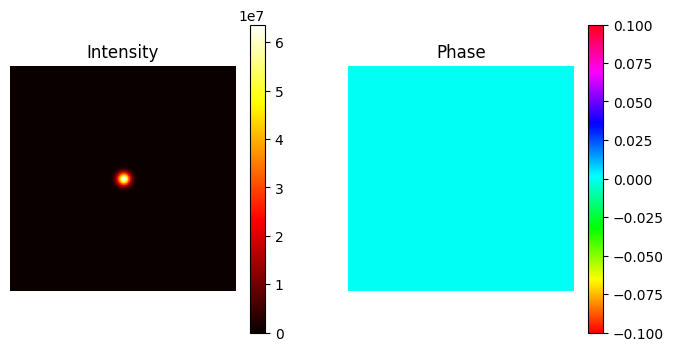

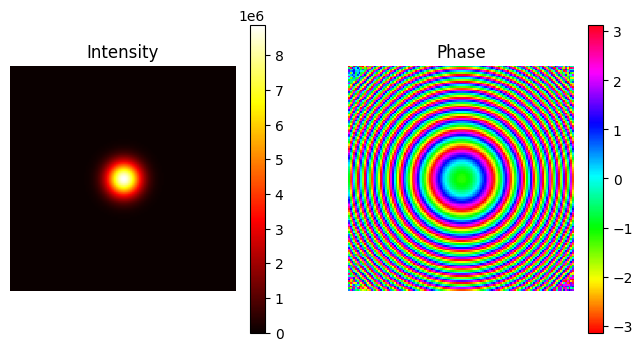

In [9]:
TotInt(field)
TotInt(prop_field)